<a href="https://colab.research.google.com/github/just-hw/GEN_HW1/blob/main/Hometasks/Base/GenDL_HT1_base_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

## Зачем это задание в нашем курсе про генеративные модели

Обучать генеративные модели интереснее всего — это понятно. Но сначала полезно один раз пройти весь пайплайн целиком: взять предобученную модель, измерить, где она ошибается, собрать данные под эту ошибку, дообучить, измерить снова. Этот цикл не зависит ни от задачи, ни от модальности — дальше в курсе вы будете крутить его же, только для изображений.

Задачу мы выбрали такую, где есть однозначная метрика. WER считается по эталонной расшифровке, и вы сразу видите, помогло ваше изменение или нет. В генерации картинок обратная связь честной уже не будет, поэтому тренируемся там, где она есть.

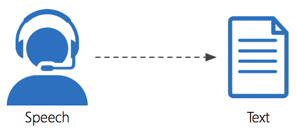

In [1]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

In [30]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch
import torchaudio
# также вам может пригодиться установить распознавание русского языка как гиперпараметр whisper-small, так как наш датасет русскоязычный

Скачиваем данные

In [12]:
# !pip install ffmpeg-python

In [6]:
import requests
import pandas as pd
download_url = requests.get(
    "https://cloud-api.yandex.net/v1/disk/public/resources/download",
    params={"public_key": "https://disk.yandex.ru/d/v2Hipv7XG4fEDQ"}
).json()["href"]

In [16]:
df = pd.read_csv(download_url, sep="\t", header=None, names=["url"])
df

,url
0,http://storage.mds.yandex.net:80/get-voicetolo...
1,http://storage.mds.yandex.net:80/get-voicetolo...
2,http://storage.mds.yandex.net:80/get-voicetolo...
3,http://storage.mds.yandex.net:80/get-voicetolo...
4,http://storage.mds.yandex.net:80/get-voicetolo...
...,...
95,http://storage.mds.yandex.net:80/get-voicetolo...
96,http://storage.mds.yandex.net:80/get-voicetolo...
97,http://storage.mds.yandex.net:80/get-voicetolo...
98,http://storage.mds.yandex.net:80/get-voicetolo...


In [27]:
import ffmpeg
import os
import tqdm

os.makedirs(os.path.dirname('audio/'), exist_ok=True)

def download_audio(url, output_path):
    url = str(url).strip()

    try:
        (
            ffmpeg
            .input(url)
            .output(
                output_path,
                ar=16000,
                ac=1,
                acodec="pcm_s16le"
            )
            .overwrite_output()
            .run(
                capture_stdout=True,
                capture_stderr=True
            )
        )

    except ffmpeg.Error as e:
        print(e.stderr.decode("utf-8", errors="replace"))
        raise

In [29]:
for i, url in enumerate(tqdm.tqdm(df["url"])):
    output_path = f"audio/{i:06d}.wav"

    if os.path.exists(output_path):
        continue
    download_audio(url, output_path)

100%|██████████| 100/100 [03:51<00:00,  2.32s/it]


Применяем whisper-small

## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [ ]:
# ваш код здесь

## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

### Подсказка (промт-бейзлайн)

Вам нужно придумать хороший промпт для модели, чтобы подсобрать обучающих данных.

Начать можно с этого:

```
examples_per_request = 10

asr_prompt = f"""Сгенерируй {examples_per_request} примеров исправления ошибок
распознавания речи на русском языке.

Верни JSON:
[{{"input": "текст с ошибками", "output": "исправленный текст"}}]
"""
```

Соберите этим промптом штук 30 примеров и посмотрите на них глазами. Скорее всего, вы заметите часть из следующего:

- предложения повторяются от запроса к запросу, а тематика однообразная и неподходящая
- ошибки не похожи на то, что реально выдал whisper на шаге 1 — сравните с его расшифровками
- в выборке нет ни одного примера, где исправлять нечего (input == output)
часть ответов не парсится, потому что модель дописала пояснение до или после JSON
- длина предложений скачет от двух слов до абзаца

Каждый из этих пунктов — направление для правки промпта. Подумайте:

- что модель должна знать про задачу, чтобы генерировать релевантные ошибки, и как ей это сообщить
- какие типы ошибок ASR вы видели на шаге 1 и стоит ли перечислить их явно
- как заставить модель не писать ничего, кроме JSON
- как добиться разнообразия между запросами, если промпт каждый раз один и тот же
- что произойдёт с дообученной моделью, если в данных нет ни одного корректного предложения

Правьте промпт по одному изменению за раз и смотрите, что поменялось в выдаче. Перед сохранением датасета не забудьте убрать дубликаты — их будет больше, чем кажется.


In [ ]:
# зайдите на страницу и создайте API KEY: https://console.groq.com/keys - возможно, понадобится включить VPN

import os

os.environ["GROQ_API_KEY"] = <YOUR API KEY>

In [ ]:
!pip install groq

In [ ]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

response = client.chat.completions.create(
    messages=[{"role": "user", "content": <YOUR PROMPT>}],
    model="openai/gpt-oss-20b", # можно брать и другие доступные у groq модели
)

print(response.choices[0].message.content)

In [ ]:
# Ваш код для подключения к Groq и промпты

In [ ]:
# Сохраните собранный датасет в файл и прикрепите сюда ссылку на него

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [ ]:
!pip install --upgrade transformers datasets

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

# Модель
...

# Загружаем свой CSV с парами (input → target)
...

# Токенизация
...

# Data collator
...

# Аргументы обучения
training_args = Seq2SeqTrainingArguments(...)

# Trainer
trainer = Seq2SeqTrainer(...)

# Запускаем обучение
trainer.train()

# Сохраняем дообученную модель
trainer.save_model("...")
tokenizer.save_pretrained("...")

Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Загружаем дообученную модель
model_path = "..."
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# Применение модели к 10 примерам
...

## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [ ]:
# ваш код здесь

## Шаг 6 (2.5 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

In [ ]:
# ваши эксперименты здесь

## Дополнение к шагу 1: декодирование и его артефакты (0.5 балла)

Эти два эксперимента — про саму модель whisper-small «как есть», без spell-correction и без дообучения (они будут в следующих шагах). Здесь нас интересует не качество распознавания само по себе, а то, как устроена генерация токен за токеном.

**а) Стратегия декодирования (0.25 балла)**

Декодер whisper-small — авторегрессионный трансформер: он порождает расшифровку токен за токеном, ровно тем же механизмом, что и языковые модели с лекции. Только префикс здесь не текстовый, а представление аудио. При этом то, какой токен окажется выбран на каждом шаге, определяется не только весами модели, но и стратегией декодирования.

Сравните на одной и той же выборке аудио несколько режимов генерации и посчитайте WER для каждого (эталонные расшифровки — тот же файл с ответами, что и в шаге 5; здесь мы просто используем его раньше по ходу задания):

- жадное декодирование: num_beams=1, do_sample=False
- лучевой поиск: num_beams=5 (попробуйте и другие значения)
- сэмплирование с температурой: do_sample=True и temperature из, например, [0.2, 0.7, 1.0]

Все эти параметры передаются в model.generate(...).

Сделайте выводы:

- какой режим дал наименьший WER и почему
что происходит с качеством при росте температуры
почему для распознавания речи температура ведёт себя не так, как для свободной генерации текста, где разнообразие ответа часто является плюсом

**б) Галлюцинации модели (0.25 балла)**

Whisper известен тем, что на тишине, шуме или музыке без речи уверенно выдаёт связный и грамматически правильный, но полностью выдуманный текст.

Найдите в датасете хотя бы один такой пример — либо сконструируйте его сами, подав на вход несколько секунд тишины или шума

Приведите расшифровку, которую выдала модель

Объясните, почему авторегрессионная модель в этой ситуации порождает правдоподобный текст, а не отказывается отвечать. Что именно она оптимизирует на каждом шаге генерации?
Предложите способ отлавливать такие случаи автоматически.

In [ ]:
# (а): сравнение стратегий декодирования
# Прогоните одну и ту же выборку аудио через несколько наборов параметров generate
# и посчитайте WER для каждого набора.

# decoding_configs = {
#     "greedy":      dict(num_beams=1, do_sample=False),
#     "beam_5":      dict(num_beams=5, do_sample=False),
#     "sample_t0.2": dict(do_sample=True, temperature=0.2),
#     "sample_t0.7": dict(do_sample=True, temperature=0.7),
#     "sample_t1.0": dict(do_sample=True, temperature=1.0),
# }

# ваш код здесь


#(б): галлюцинации на тишине/шуме
# Подсказка для конструирования примера:
# silence = torch.zeros(1, 16000 * 5)          # 5 секунд тишины
# noise   = torch.randn(1, 16000 * 5) * 0.01   # 5 секунд слабого шума

# ваш код здесь
